In [1]:
from coffea.util import load
summer23bpix = load("../BTVNanoCommissioning/hists_validation_bpix_tt/hists_validation_bpix_tt.coffea")
summer23 = load("../BTVNanoCommissioning/hists_validation_summer23tt/hists_validation_summer23tt.coffea")
summer22 = load("../BTVNanoCommissioning/hists_validation_MC_Summer22_Run3_2022_BTV_Comm_v2_NanoV12_noPF/hists_validation_MC_Summer22_Run3_2022_BTV_Comm_v2_NanoV12_noPF.coffea")
summer22ee = load("../BTVNanoCommissioning/hists_validation_MC_Summer22EE_Run3_2022_BTV_Comm_v2_NanoV12_noPF/hists_validation_MC_Summer22EE_Run3_2022_BTV_Comm_v2_NanoV12_noPF.coffea")

In [23]:
len(summer22[list(summer22.keys())[0]]['btagDeepB_0'][0,3,:].values())

50

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fae025f49a0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

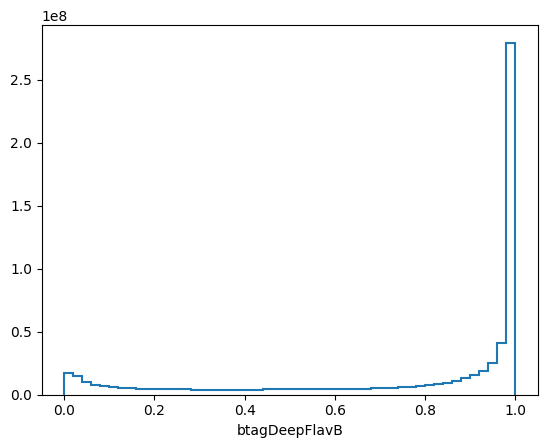

In [17]:
import matplotlib.pyplot as plt
import mplhep as hep
tagger=['btagDeepFlav','btagPNet','btagParTAK4']
score=['B_0',"CvL_0","CvB_0"]
collect={}
collect['Summer22'],collect['Summer22_postEE'],collect['Summer23'],collect['Summer23_BPix']={},{},{},{}
for sc in score:
    collect['Summer22'][sc],collect['Summer22_postEE'][sc],collect['Summer23'][sc],collect['Summer23_BPix'][sc]={},{},{},{}
    for tag in tagger:
        collect['Summer22'][sc][tag]=[np.sum(summer22[list(summer22.keys())[0]][tag+sc][0,3,:].values()[i:])/np.sum(summer22[list(summer22.keys())[0]][tag+sc][0,3,:].values()) for i in range(50)]
        collect['Summer22EE'][sc][tag]=[np.sum(summer22ee[list(summer22ee.keys())[0]][tag+sc][0,3,:].values()[i:])/np.sum(summer22ee[list(summer22ee.keys())[0]][tag+sc][0,3,:].values()) for i in range(50)]
        collect['Summer23'][sc][tag]=[np.sum(summer23[list(summer23.keys())[0]][tag+sc][0,3,:].values()[i:])/np.sum(summer23[list(summer23.keys())[0]][tag+sc][0,3,:].values()) for i in range(50)]
        collect['Summer23BPix'][sc][tag]=[np.sum(summer23[list(summer23.keys())[0]][tag+sc][0,3,:].values()[i:])/np.sum(summer23[list(summer23.keys())[0]][tag+sc][0,3,:].values()) for i in range(50)]

In [1]:
from coffea.util import load
out=load("../BTVNanoCommissioning/hists_ttdilep_sf_prompt_NANO/hists_ttdilep_sf_prompt_NANO.coffea")
outt=load("../BTVNanoCommissioning/hists_ttdilep_sf_data_Summer22EE_fixed.coffea")

1.0200956937799044

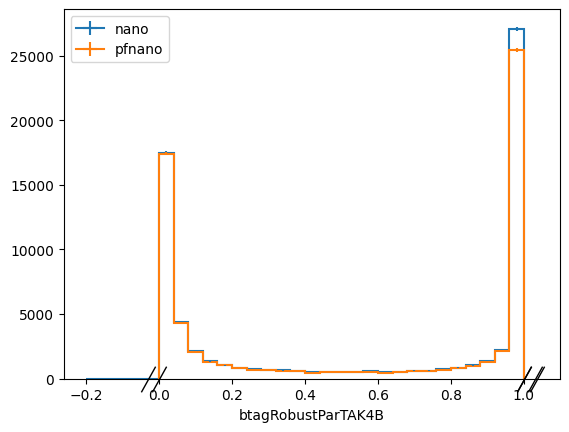

In [4]:
import mplhep as hep
import matplotlib.pyplot as plt
import hist
hep.histplot(out['MuonEGRun2022F-22Sep2023-v1']['btagRobustParTAK4B_0'][0,sum,:],label='nano')
hep.histplot(outt['MuonEGRun2022F-PromptReco-v1']['btagRobustParTAK4B_0'][0,sum,hist.rebin(2)],label='pfnano')
plt.legend()
# plt.xlabel("jet pT")
import numpy as np
np.sum(out['MuonEGRun2022F-22Sep2023-v1']['jet0_pt'][0,sum,:].values()[5:])/np.sum(outt['MuonEGRun2022F-PromptReco-v1']['jet0_pt'][0,sum,:].values())
# out['MuonEGRun2022F-22Sep2023-v1']['jet0_pt']

(0.9, 1.2)

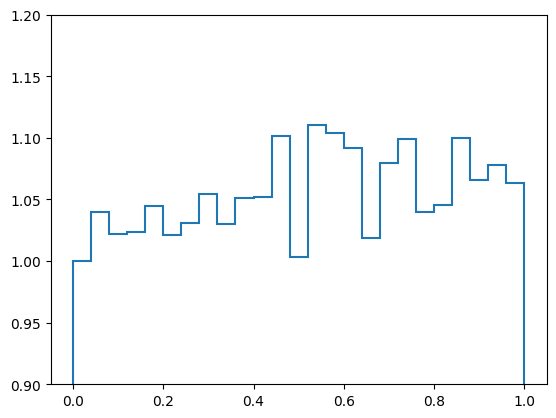

In [36]:
hep.histplot(out['MuonEGRun2022F-22Sep2023-v1']['btagDeepFlavB_0'][0,sum,:].values()[5:]/outt['MuonEGRun2022F-PromptReco-v1']['btagDeepFlavB_0'][0,sum,hist.rebin(2)].values(),outt['MuonEGRun2022F-PromptReco-v1']['btagDeepFlavCvL_0'][0,sum,hist.rebin(2)].axes[0].edges,label='nano')
plt.ylim(0.9,1.2)

In [1]:
import uproot
f=uproot.open("test_MINI_NANO.root:Events")
fb=uproot.open("off_v12.root:Events")
event=f.arrays()
event_off=fb.arrays()

In [6]:
f2=uproot.open("runC_old_pf.root:Events")
event_old=f2.arrays()

Text(0.5, 0, 'DeepJet BvAll')

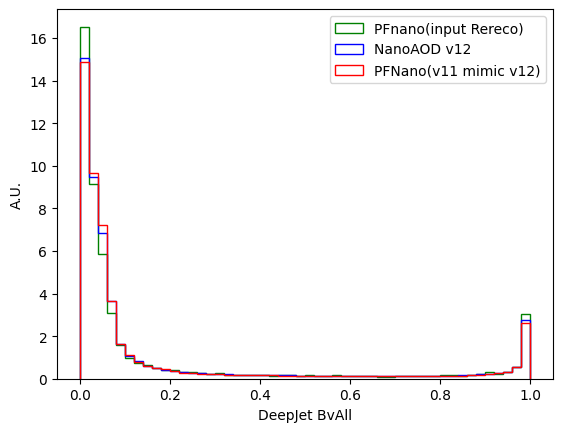

In [12]:
import matplotlib.pyplot as plt
import awkward as ak
plt.hist(ak.flatten(event["Jet_btagDeepFlavB"],axis=None),range=[0,1],bins=50,histtype='step',density=True,label='PFnano(input Rereco)',color='green')
plt.hist(ak.flatten(event_off["Jet_btagDeepFlavB"],axis=None),range=[0,1],bins=50,histtype='step',density=True,label='NanoAOD v12',color='blue')
plt.hist(ak.flatten(event_old["Jet_btagDeepFlavB"],axis=None),range=[0,1],bins=50,histtype='step',density=True,label='PFNano(v11 mimic v12)',color='red')
plt.legend()
plt.ylabel("A.U.")
plt.xlabel("DeepJet BvAll")

Text(0.5, 0, 'Jet pT')

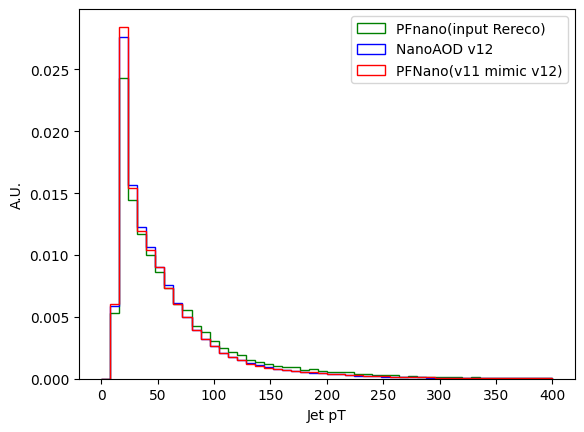

In [11]:
plt.hist(ak.flatten(event["Jet_pt"],axis=None),range=[0,400],bins=50,histtype='step',density=True,label='PFnano(input Rereco)',color='green')
plt.hist(ak.flatten(event_off["Jet_pt"],axis=None),range=[0,400],bins=50,histtype='step',density=True,label='NanoAOD v12',color='blue')
plt.hist(ak.flatten(event_old["Jet_pt"],axis=None),range=[0,400],bins=50,histtype='step',density=True,label='PFNano(v11 mimic v12)',color='red')
plt.legend()
plt.ylabel("A.U.")
plt.xlabel("Jet pT")